In [1]:
# -------------------------------
# Imports
# -------------------------------
import numpy as np
import pandas as pd
import optuna
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score
import time
import gc
import warnings
warnings.filterwarnings('ignore')



# from sklearnex import patch_sklearn
# patch_sklearn()  # patches scikit-learn algorithms
# from sklearnex import unpatch_sklearn
# unpatch_sklearn()
# -------------------------------


# Load Data
# -------------------------------
X_train = pd.read_csv('../data/X_train_encoded.csv')
X_test  = pd.read_csv('../data/X_test_encoded.csv')
y_train = pd.read_csv('../data/y_train.csv')
test_ids = X_test['PassengerId']
X_test.drop(columns=['PassengerId'], inplace=True)

# Flatten target if needed
# Map target to numeric
target = 'Survived'

y_train_numeric = y_train[target]


num_classes = len(np.unique(y_train_numeric))
print(f"Number of classes: {num_classes}")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Number of classes: 2
X_train shape: (891, 13)
X_test shape: (418, 13)


In [8]:
# =========================
# HistGradientBoosting Classifier
# =========================
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score
import pandas as pd
import numpy as np
import gc

# =========================
# Model
# =========================
hgb_model = HistGradientBoostingClassifier(
    loss='log_loss',
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=50,
    random_state=42
)

# =========================
# Hyperparameter grid for tuning
# =========================
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'max_depth': [3, 5, 7, 10, 15],
    'max_leaf_nodes': [15, 31, 50, 100, 255],
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'max_iter': [200, 500, 1000, 1500, 2000],
    'l2_regularization': [0.0, 0.01, 0.1, 0.5, 1.0]
}

# =========================
# RandomizedSearchCV
# =========================
random_search = RandomizedSearchCV(
    estimator=hgb_model,
    param_distributions=param_grid,
    n_iter=50,           # number of random combinations
    scoring='accuracy',
    cv=5,
    verbose=2,
    random_state=42
)

# =========================
# Fit on training data
# =========================
random_search.fit(X_train, y_train_numeric)

# Best model
best_model = random_search.best_estimator_
print("Best Hyperparameters:", random_search.best_params_)

# =========================
# Evaluate on training data
# =========================
y_train_pred_proba = best_model.predict_proba(X_train)[:, 1]
y_train_pred_class = best_model.predict(X_train)

roc_auc = roc_auc_score(y_train_numeric, y_train_pred_proba)
logloss = log_loss(y_train_numeric, y_train_pred_proba)
accuracy = accuracy_score(y_train_numeric, y_train_pred_class)

print("\nTraining final model on full training data...")
print(f"Train ROC AUC: {roc_auc:.5f}")
print(f"Train Log Loss: {logloss:.5f}")
print(f"Train Accuracy: {accuracy:.5f}")

# =========================
# Predict on test data
# =========================
y_pred = best_model.predict(X_test)
y_pred_class = (y_pred >= 0.5).astype(int) if y_pred.ndim == 2 else y_pred  # handle binary output

# =========================
# Save submission
# =========================
submission = pd.DataFrame({
    "PassengerId": test_ids,  # replace with proper ID column from your test set
    "Survived": y_pred_class
})

submission.to_csv('submission/hgb_w_RSearchCV_submission.csv', index=False)
print("Submission saved as hgb_w_RSearchCV_submission.csv")

gc.collect()


Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END l2_regularization=0.1, learning_rate=0.05, max_depth=10, max_iter=200, max_leaf_nodes=255, min_samples_leaf=5; total time=   0.3s
[CV] END l2_regularization=0.1, learning_rate=0.05, max_depth=10, max_iter=200, max_leaf_nodes=255, min_samples_leaf=5; total time=   0.3s
[CV] END l2_regularization=0.1, learning_rate=0.05, max_depth=10, max_iter=200, max_leaf_nodes=255, min_samples_leaf=5; total time=   0.3s
[CV] END l2_regularization=0.1, learning_rate=0.05, max_depth=10, max_iter=200, max_leaf_nodes=255, min_samples_leaf=5; total time=   0.4s
[CV] END l2_regularization=0.1, learning_rate=0.05, max_depth=10, max_iter=200, max_leaf_nodes=255, min_samples_leaf=5; total time=   0.4s
[CV] END l2_regularization=0.0, learning_rate=0.05, max_depth=5, max_iter=2000, max_leaf_nodes=50, min_samples_leaf=5; total time=   0.1s
[CV] END l2_regularization=0.0, learning_rate=0.05, max_depth=5, max_iter=2000, max_leaf_nodes=50, min_sa

27

In [ ]:

# -------------------------------
# Optuna objective for Gradient Boosting
# -------------------------------
def objective(trial):

    params = {
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 15, 255),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 100),
        'l2_regularization': trial.suggest_float('l2_regularization', 1e-6, 10.0, log=True),
        'max_iter': trial.suggest_int('max_iter', 200, 1000), # was 2000
        # 'early_stopping': True,
        # 'validation_fraction': 0.1,
        # 'n_iter_no_change': 50,
        'random_state': 42
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    logloss_scores = []

    for fold, (train_idx, valid_idx) in enumerate(
        skf.split(X_train, y_train_numeric)
    ):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train_numeric[train_idx], y_train_numeric[valid_idx]

        model = HistGradientBoostingClassifier(
            loss='log_loss',
            **params
        )

        model.fit(X_tr, y_tr)

        pred_val = model.predict_proba(X_val)
        fold_logloss = log_loss(y_val, pred_val)

        logloss_scores.append(fold_logloss)

        # ---- Optuna pruning (fold-based) ----
        trial.report(fold_logloss, step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(logloss_scores)


In [7]:

# -------------------------------
# Optuna study
# -------------------------------
debug = True
timeout = 60 if debug else 3600

start = time.time()

sampler = optuna.samplers.TPESampler(
    n_startup_trials=30,
    multivariate=True
)

pruner = optuna.pruners.SuccessiveHalvingPruner(
    min_resource=2,
    reduction_factor=4,
    min_early_stopping_rate=1
)

study = optuna.create_study(
    direction='minimize',
    sampler=sampler,
    pruner=pruner
)

study.optimize(objective, n_trials=30, timeout=timeout)

end = time.time()

print(f"Optuna finished in {end - start:.2f} seconds")
print("Best params:", study.best_params)
print("Best CV multi_logloss:", study.best_value)

# -------------------------------
# Train final Gradient Boosting model
# -------------------------------
best_params = study.best_params
best_params.update({
    'early_stopping': False, # was true
    # 'validation_fraction': 0.1,
    # 'n_iter_no_change': 50,
    'random_state': 42
})

print("\nTraining final Gradient Boosting model on full training data...")
final_model = HistGradientBoostingClassifier(
    loss='log_loss',
    **best_params
)

final_model.fit(X_train, y_train_numeric)

# -------------------------------
# Evaluate on train set
# -------------------------------
# Use predict_proba for metrics
pred_train_proba = final_model.predict_proba(X_train)  # shape: (n_samples, 2)
pred_train_class = np.argmax(pred_train_proba, axis=1)  # class labels 0/1

# Metrics
roc_auc = roc_auc_score(y_train_numeric, pred_train_proba[:, 1])  # probabilities for positive class
logloss = log_loss(y_train_numeric, pred_train_proba)
accuracy = np.mean(pred_train_class == y_train_numeric)

print("\n--- Training set performance ---")
print(f"Train ROC AUC: {roc_auc:.5f}")
print(f"Train Log Loss: {logloss:.5f}")
print(f"Train Accuracy: {accuracy:.5f}")



# -------------------------------
# Evaluate on test set
# -------------------------------
pred_test = final_model.predict_proba(X_test)
# pred_test_pos = pred_test[:, 1]
pred_test_class = np.argmax(pred_test, axis=1)


# roc_auc = roc_auc_score(y_test_numeric, pred_test_pos)
# logloss = log_loss(y_test_numeric, pred_test)
# #logloss = log_loss(y_test_numeric, pred_test)
# #accuracy = np.mean(np.argmax(pred_test, axis=1) == y_test_numeric)

# print("\n--- Test set performance ---")
# print(f"ROC AUC (OVR weighted): {roc_auc:.5f}")
# #print(f"Log Loss:           {logloss:.5f}")
# #print(f"Accuracy:           {accuracy:.5f}")


submission = pd.DataFrame({
    "PassengerId": test_ids,  # replace with your ID column
    "Survived": pred_test_class
})
submission.to_csv("submission/hgb_optuna_submission.csv", index=False)
print("Submission saved!")

gc.collect()



[I 2026-02-09 17:44:59,129] A new study created in memory with name: no-name-41f86893-d22a-4a12-98c0-19c116c14f8f
[I 2026-02-09 17:44:59,841] Trial 0 finished with value: 0.4730515499213265 and parameters: {'learning_rate': 0.26033442117930516, 'max_depth': 8, 'max_leaf_nodes': 249, 'min_samples_leaf': 27, 'l2_regularization': 0.0036076017162670975, 'max_iter': 863}. Best is trial 0 with value: 0.4730515499213265.
[I 2026-02-09 17:45:00,890] Trial 1 finished with value: 0.49837190729746056 and parameters: {'learning_rate': 0.13842624479882037, 'max_depth': 7, 'max_leaf_nodes': 166, 'min_samples_leaf': 8, 'l2_regularization': 5.1631740521503906e-05, 'max_iter': 968}. Best is trial 0 with value: 0.4730515499213265.
[I 2026-02-09 17:45:02,454] Trial 2 finished with value: 0.42093160244862526 and parameters: {'learning_rate': 0.025975453652634168, 'max_depth': 9, 'max_leaf_nodes': 153, 'min_samples_leaf': 49, 'l2_regularization': 0.0001422617829308899, 'max_iter': 967}. Best is trial 2 wit

Optuna finished in 39.85 seconds
Best params: {'learning_rate': 0.004371958052931485, 'max_depth': 12, 'max_leaf_nodes': 74, 'min_samples_leaf': 30, 'l2_regularization': 4.224867261532437e-05, 'max_iter': 869}
Best CV multi_logloss: 0.4140322181713868

Training final Gradient Boosting model on full training data...

--- Training set performance ---
Train ROC AUC: 0.91766
Train Log Loss: 0.34287
Train Accuracy: 0.86644
Submission saved!


0

In [23]:
import joblib
import numpy as np
import os
from sklearn.metrics import roc_auc_score, log_loss

folder = "models"
version = "v2"

# -------------------------------
# Save test predictions
# -------------------------------
pred_test_pos = final_model.predict_proba(X_test)[:, 1]
roc_auc_test = roc_auc_score(y_test_numeric, pred_test_pos)
auc_str = f"{roc_auc_test:.2f}".replace(".", "p")  # e.g., 0.71 -> 0p71

# Save final model
model_path = os.path.join(folder, f"gradient_boosting_{version}_{auc_str}AUC_optuna.pkl")
joblib.dump(final_model, model_path)
print(f"Saved model: {model_path}")

# Save "OOF" train predictions (here we just use full training set as proxy)
if hasattr(final_model, "predict_proba"):
    oof_train = final_model.predict_proba(X_train)[:, 1]
else:
    oof_train = final_model.predict(X_train)
oof_path = os.path.join(folder, f"gradient_boosting_{version}_{auc_str}AUC_oof_train.npy")
np.save(oof_path, oof_train)
print(f"Saved OOF train predictions: {oof_path}")

# Save test predictions
pred_path = os.path.join(folder, f"gradient_boosting_{version}_{auc_str}AUC_pred_test.npy")
np.save(pred_path, pred_test_pos)
print(f"Saved test predictions: {pred_path}")


Saved model: models/gradient_boosting_v2_0p71AUC_optuna.pkl
Saved OOF train predictions: models/gradient_boosting_v2_0p71AUC_oof_train.npy
Saved test predictions: models/gradient_boosting_v2_0p71AUC_pred_test.npy


# For Stacking

In [11]:
import os
import gc
import time
import numpy as np
import pandas as pd
import optuna
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score

# -------------------------------
# Load data
# -------------------------------
X_train = pd.read_csv('../data/X_train_encoded.csv')
X_test = pd.read_csv('../data/X_test_encoded.csv')
y_train = pd.read_csv('../data/y_train.csv')
test_ids = X_test['PassengerId']
X_test.drop(columns=['PassengerId'], inplace=True)

y_train_numeric = y_train['Survived']

# -------------------------------
# Load precomputed folds
# -------------------------------
folds_path = './fold_indices.npy'
folds = np.load(folds_path, allow_pickle=True)
print(f"Loaded {len(folds)} folds")

# -------------------------------
# Prepare OOF and test prediction arrays
# -------------------------------
oof_preds = np.zeros(len(X_train))
test_preds = np.zeros(len(X_test))

# -------------------------------
# Optuna objective function for HGB
# -------------------------------
def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 15, 255),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 100),
        'l2_regularization': trial.suggest_float('l2_regularization', 1e-6, 10.0, log=True),
        'max_iter': trial.suggest_int('max_iter', 200, 1000),
        'random_state': 42
    }

    fold_logloss = []

    for fold_num, (train_idx, valid_idx) in enumerate(folds):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train_numeric.iloc[train_idx], y_train_numeric.iloc[valid_idx]

        model = HistGradientBoostingClassifier(loss='log_loss', **params)
        model.fit(X_tr, y_tr)

        pred_val = model.predict_proba(X_val)[:, 1]  # probability for class 1
        fold_logloss.append(log_loss(y_val, pred_val))

        # Optuna pruning
        trial.report(fold_logloss[-1], step=fold_num)
        if trial.should_prune():
            raise optuna.TrialPruned()

        del X_tr, X_val, y_tr, y_val, model, pred_val
        gc.collect()

    return np.mean(fold_logloss)

# -------------------------------
# Run Optuna study
# -------------------------------
debug = True
timeout = 60 if debug else 3600
start = time.time()

sampler = optuna.samplers.TPESampler(n_startup_trials=10, multivariate=True)
pruner = optuna.pruners.SuccessiveHalvingPruner(
    min_resource=2, reduction_factor=4, min_early_stopping_rate=1
)

study = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=30, timeout=timeout)

end = time.time()
print(f"Optuna finished in {end - start:.2f} seconds")
print("Best params:", study.best_params)
print("Best CV logloss:", study.best_value)

# -------------------------------
# Train final HGB model (OOF + test preds)
# -------------------------------
best_params = study.best_params
best_params.update({'random_state': 42})

for fold_num, (train_idx, valid_idx) in enumerate(folds):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
    y_tr, y_val = y_train_numeric.iloc[train_idx], y_train_numeric.iloc[valid_idx]

    model = HistGradientBoostingClassifier(loss='log_loss', **best_params)
    model.fit(X_tr, y_tr)

    # OOF predictions
    oof_preds[valid_idx] = model.predict_proba(X_val)[:, 1]

    # Test predictions (average across folds)
    test_preds += model.predict_proba(X_test)[:, 1] / len(folds)

    print(f"Fold {fold_num} done.")
    del X_tr, X_val, y_tr, y_val, model
    gc.collect()

# -------------------------------
# Save OOF and test predictions
# -------------------------------
os.makedirs('oof_preds', exist_ok=True)
os.makedirs('test_preds', exist_ok=True)
np.save('oof_preds/hgb_optuna_oof.npy', oof_preds)
np.save('test_preds/hgb_optuna_test.npy', test_preds)
print("OOF and test predictions saved!")

# -------------------------------
# Optional: create submission using test_preds
# -------------------------------
y_pred_class = (test_preds >= 0.5).astype(int)
submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Survived": y_pred_class
})
os.makedirs('submission', exist_ok=True)
submission.to_csv("submission/hgb_optuna_submission.csv", index=False)
print("Submission saved!")


[I 2026-02-09 20:40:59,549] A new study created in memory with name: no-name-19145d62-018c-4cdc-a10f-f778f4ea54a3


Loaded 5 folds


[I 2026-02-09 20:41:03,097] Trial 0 finished with value: 0.4247994815794202 and parameters: {'learning_rate': 0.05013252448788839, 'max_depth': 8, 'max_leaf_nodes': 164, 'min_samples_leaf': 48, 'l2_regularization': 0.21633555419254083, 'max_iter': 215}. Best is trial 0 with value: 0.4247994815794202.
[I 2026-02-09 20:41:15,156] Trial 1 finished with value: 0.48761802167331203 and parameters: {'learning_rate': 0.0010081681414969355, 'max_depth': 7, 'max_leaf_nodes': 68, 'min_samples_leaf': 7, 'l2_regularization': 0.16569232101324136, 'max_iter': 673}. Best is trial 0 with value: 0.4247994815794202.
[I 2026-02-09 20:41:16,312] Trial 2 finished with value: 0.4457835870135094 and parameters: {'learning_rate': 0.006972426166793214, 'max_depth': 9, 'max_leaf_nodes': 31, 'min_samples_leaf': 46, 'l2_regularization': 0.7242431170964572, 'max_iter': 234}. Best is trial 0 with value: 0.4247994815794202.
[I 2026-02-09 20:41:18,244] Trial 3 finished with value: 0.46277818498081735 and parameters: {

Optuna finished in 61.93 seconds
Best params: {'learning_rate': 0.03152726457825065, 'max_depth': 12, 'max_leaf_nodes': 135, 'min_samples_leaf': 46, 'l2_regularization': 5.71685485703623e-06, 'max_iter': 268}
Best CV logloss: 0.42091312715612617
Fold 0 done.
Fold 1 done.
Fold 2 done.
Fold 3 done.
Fold 4 done.
OOF and test predictions saved!
Submission saved!


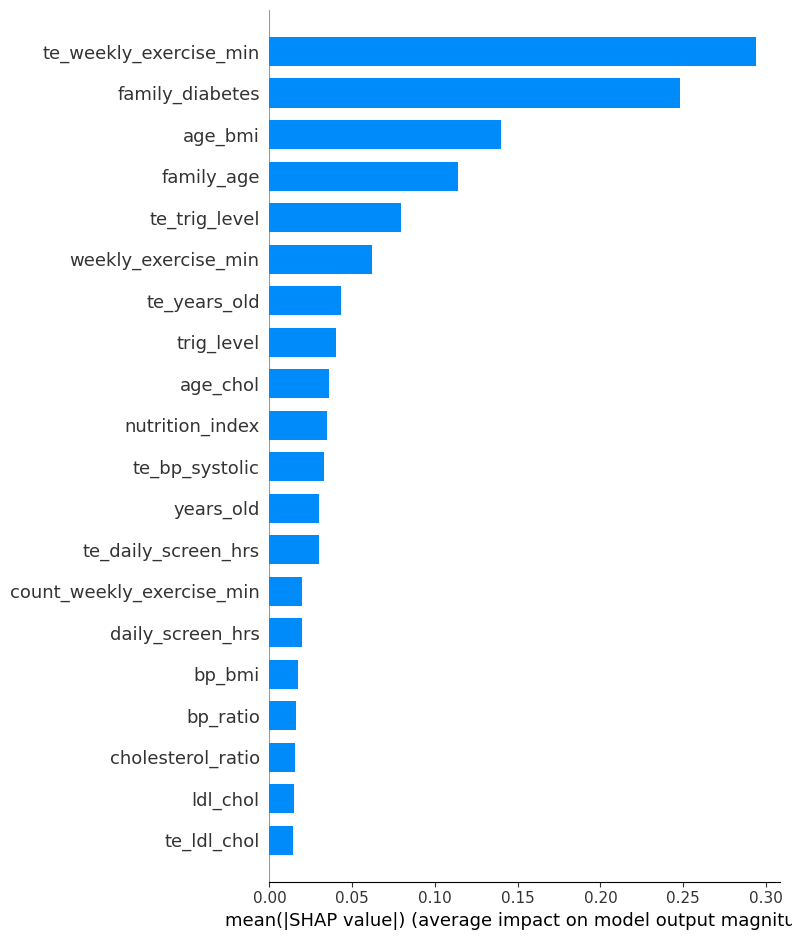

In [24]:
import shap
import numpy as np
X_shap = X_train.sample(1000, random_state=42)  # reduce if slow
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap)
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    class_names=[f"Class {i}" for i in range(len(shap_values))]
)

# ExtraTrees

In [9]:
# -------------------------------
# Optuna objective for ExtraTrees
# -------------------------------
from sklearn.ensemble import ExtraTreesClassifier


def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 2000),
        'max_depth': trial.suggest_int('max_depth', 5, 40),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 30),
        'max_features': trial.suggest_float('max_features', 0.3, 1.0),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'class_weight': trial.suggest_categorical(
            'class_weight', [None, 'balanced', 'balanced_subsample']
        ),
        'n_jobs': -1,
        'random_state': 2026
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    logloss_scores = []

    for fold, (train_idx, valid_idx) in enumerate(
        skf.split(X_train, y_train_numeric)
    ):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train_numeric[train_idx], y_train_numeric[valid_idx]

        model = ExtraTreesClassifier(**params)
        model.fit(X_tr, y_tr)

        pred_val = model.predict_proba(X_val)
        fold_logloss = log_loss(y_val, pred_val)
        logloss_scores.append(fold_logloss)

        # ---- Optuna pruning (fold-based) ----
        trial.report(fold_logloss, step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
        
        # Cleanup per fold to save memory
        del X_tr, X_val, y_tr, y_val, model, pred_val
        gc.collect()

    return np.mean(logloss_scores)

# -------------------------------
# Optuna study
# -------------------------------
debug = True
timeout = 60 if debug else 3600

start = time.time()

sampler = optuna.samplers.TPESampler(
    n_startup_trials=30,
    multivariate=True
)

pruner = optuna.pruners.SuccessiveHalvingPruner(
    min_resource=2,
    reduction_factor=4,
    min_early_stopping_rate=1
)

study = optuna.create_study(
    direction='minimize',
    sampler=sampler,
    pruner=pruner
)

study.optimize(objective, n_trials=30, timeout=timeout)

end = time.time()

print(f"Optuna finished in {end - start:.2f} seconds")
print("Best params:", study.best_params)
print("Best CV multi_logloss:", study.best_value)

# -------------------------------
# Train final ExtraTrees model
# -------------------------------
best_params = study.best_params
best_params.update({
    'n_jobs': -1,
    'random_state': 42
})

print("\nTraining final ExtraTrees model on full training data...")
final_model = ExtraTreesClassifier(**best_params)
final_model.fit(X_train, y_train_numeric)


# -------------------------------
# Evaluate on training set
# -------------------------------
pred_train_proba = final_model.predict_proba(X_train)[:, 1]          # probabilities for class 1
pred_train_class = (pred_train_proba >= 0.5).astype(int)             # hard labels

roc_auc = roc_auc_score(y_train_numeric, pred_train_proba)
logloss = log_loss(y_train_numeric, pred_train_proba)
accuracy = np.mean(pred_train_class == y_train_numeric)

print("\n--- Train set performance ---")
print(f"Train ROC AUC: {roc_auc:.5f}")
print(f"Train Log Loss: {logloss:.5f}")
print(f"Train Accuracy: {accuracy:.5f}")

# -------------------------------
# Evaluate on test set (binary)
# -------------------------------
y_pred_test = final_model.predict(X_test)  # class labels 0/1


submission = pd.DataFrame({
    "PassengerId": test_ids,  # make sure test_ids is loaded from test CSV
    "Survived": y_pred_test
})
submission.to_csv("submission/extratrees_optuna_submission.csv", index=False)

gc.collect()
print("Submission file created!")
# # Use probability for positive class (class 1)
# pred_test_pos = pred_test[:, 1]  # shape: (n_samples,)

# # ROC AUC
# roc_auc = roc_auc_score(y_test_numeric, pred_test_pos)

# # Log loss (still works with 2D probabilities)
# logloss = log_loss(y_test_numeric, pred_test)

# # Accuracy
# accuracy = np.mean((pred_test_pos > 0.5) == y_test_numeric)

# print("\n--- Test set performance ---")
# print(f"ROC AUC: {roc_auc:.5f}")
# print(f"Log Loss: {logloss:.5f}")
# print(f"Accuracy: {accuracy:.5f}")

gc.collect()


[I 2026-02-09 18:06:52,899] A new study created in memory with name: no-name-d2d4bae7-ee19-4e28-82a6-9d24458ea093
[I 2026-02-09 18:07:02,206] Trial 0 finished with value: 0.42680825622318086 and parameters: {'n_estimators': 1922, 'max_depth': 13, 'min_samples_split': 29, 'min_samples_leaf': 10, 'max_features': 0.9274174399816875, 'bootstrap': False, 'class_weight': None}. Best is trial 0 with value: 0.42680825622318086.
[I 2026-02-09 18:07:12,622] Trial 1 finished with value: 0.43306998208273717 and parameters: {'n_estimators': 1582, 'max_depth': 40, 'min_samples_split': 21, 'min_samples_leaf': 8, 'max_features': 0.7519191012544855, 'bootstrap': True, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.42680825622318086.
[I 2026-02-09 18:07:22,298] Trial 2 finished with value: 0.4537029666909029 and parameters: {'n_estimators': 1004, 'max_depth': 22, 'min_samples_split': 7, 'min_samples_leaf': 27, 'max_features': 0.6399825104980991, 'bootstrap': True, 'class_weight': 'balanced_s

Optuna finished in 65.89 seconds
Best params: {'n_estimators': 1922, 'max_depth': 13, 'min_samples_split': 29, 'min_samples_leaf': 10, 'max_features': 0.9274174399816875, 'bootstrap': False, 'class_weight': None}
Best CV multi_logloss: 0.42680825622318086

Training final ExtraTrees model on full training data...

--- Train set performance ---
Train ROC AUC: 0.91506
Train Log Loss: 0.34874
Train Accuracy: 0.85522
Submission file created!


0

In [26]:
import joblib
import numpy as np
import os
from sklearn.metrics import roc_auc_score, log_loss

folder = "models"
os.makedirs(folder, exist_ok=True)
version = "v2"

# -------------------------------
# Test predictions
# -------------------------------
pred_test_pos = final_model.predict_proba(X_test)[:, 1]  # probability of positive class
roc_auc_test = roc_auc_score(y_test_numeric, pred_test_pos)
auc_str = f"{roc_auc_test:.2f}".replace(".", "p")  # e.g., 0.71 -> 0p71

# -------------------------------
# Save final model
# -------------------------------
model_path = os.path.join(folder, f"extra_trees_{version}_{auc_str}AUC_optuna.pkl")
joblib.dump(final_model, model_path)
print(f"Saved model: {model_path}")

# -------------------------------
# Save "OOF" train predictions
# -------------------------------
if hasattr(final_model, "predict_proba"):
    oof_train = final_model.predict_proba(X_train)[:, 1]  # full train as proxy OOF
else:
    oof_train = final_model.predict(X_train)

oof_path = os.path.join(folder, f"extra_trees_{version}_{auc_str}AUC_oof_train.npy")
np.save(oof_path, oof_train)
print(f"Saved OOF train predictions: {oof_path}")

# -------------------------------
# Save test predictions
# -------------------------------
pred_path = os.path.join(folder, f"extra_trees_{version}_{auc_str}AUC_pred_test.npy")
np.save(pred_path, pred_test_pos)
print(f"Saved test predictions: {pred_path}")


Saved model: models/extra_trees_v2_0p70AUC_optuna.pkl
Saved OOF train predictions: models/extra_trees_v2_0p70AUC_oof_train.npy
Saved test predictions: models/extra_trees_v2_0p70AUC_pred_test.npy


# Extraboost for stacking

In [10]:
import os
import gc
import time
import numpy as np
import pandas as pd
import optuna
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score


# -------------------------------
# Load precomputed folds
# -------------------------------
folds_path = './fold_indices.npy'
folds = np.load(folds_path, allow_pickle=True)
print(f"Loaded {len(folds)} folds")

# -------------------------------
# Prepare OOF and test prediction arrays
# -------------------------------
oof_preds = np.zeros(len(X_train))
test_preds = np.zeros(len(X_test))

# -------------------------------
# Optuna objective function for ExtraTrees
# -------------------------------
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 2000),
        'max_depth': trial.suggest_int('max_depth', 5, 40),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 30),
        'max_features': trial.suggest_float('max_features', 0.3, 1.0),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'class_weight': trial.suggest_categorical(
            'class_weight', [None, 'balanced', 'balanced_subsample']
        ),
        'n_jobs': -1,
        'random_state': 42
    }

    fold_logloss = []

    for fold_num, (train_idx, valid_idx) in enumerate(folds):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train_numeric.iloc[train_idx], y_train_numeric.iloc[valid_idx]

        model = ExtraTreesClassifier(**params)
        model.fit(X_tr, y_tr)

        pred_val = model.predict_proba(X_val)[:, 1]  # probability for class 1
        fold_logloss.append(log_loss(y_val, pred_val))

        # Optuna pruning
        trial.report(fold_logloss[-1], step=fold_num)
        if trial.should_prune():
            raise optuna.TrialPruned()

        del X_tr, X_val, y_tr, y_val, model, pred_val
        gc.collect()

    return np.mean(fold_logloss)

# -------------------------------
# Run Optuna study
# -------------------------------
debug = True
timeout = 60 if debug else 3600
start = time.time()

sampler = optuna.samplers.TPESampler(n_startup_trials=10, multivariate=True)
pruner = optuna.pruners.SuccessiveHalvingPruner(
    min_resource=2, reduction_factor=4, min_early_stopping_rate=1
)

study = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=30, timeout=timeout)

end = time.time()
print(f"Optuna finished in {end - start:.2f} seconds")
print("Best params:", study.best_params)
print("Best CV logloss:", study.best_value)

# -------------------------------
# Train final ExtraTrees model (OOF + test preds)
# -------------------------------
best_params = study.best_params
best_params.update({'n_jobs': -1, 'random_state': 42})

for fold_num, (train_idx, valid_idx) in enumerate(folds):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
    y_tr, y_val = y_train_numeric.iloc[train_idx], y_train_numeric.iloc[valid_idx]

    model = ExtraTreesClassifier(**best_params)
    model.fit(X_tr, y_tr)

    # OOF predictions
    oof_preds[valid_idx] = model.predict_proba(X_val)[:, 1]

    # Test predictions (average across folds)
    test_preds += model.predict_proba(X_test)[:, 1] / len(folds)

    print(f"Fold {fold_num} done.")
    del X_tr, X_val, y_tr, y_val, model
    gc.collect()

# -------------------------------
# Save OOF and test predictions
# -------------------------------
os.makedirs('oof_preds', exist_ok=True)
os.makedirs('test_preds', exist_ok=True)
np.save('oof_preds/extratrees_optuna_oof.npy', oof_preds)
np.save('test_preds/extratrees_optuna_test.npy', test_preds)
print("OOF and test predictions saved!")

# -------------------------------
# Optional: create submission using test_preds
# -------------------------------
y_pred_class = (test_preds >= 0.5).astype(int)
submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Survived": y_pred_class
})
os.makedirs('submission', exist_ok=True)
submission.to_csv("submission/extratrees_optuna_submission.csv", index=False)
print("Submission saved!")


[I 2026-02-09 20:37:56,357] A new study created in memory with name: no-name-252ebff9-5545-4a5a-aa1b-41913818e262


Loaded 5 folds


[I 2026-02-09 20:38:16,376] Trial 0 finished with value: 0.43260581390532044 and parameters: {'n_estimators': 1805, 'max_depth': 29, 'min_samples_split': 3, 'min_samples_leaf': 14, 'max_features': 0.4168554310336407, 'bootstrap': True, 'class_weight': None}. Best is trial 0 with value: 0.43260581390532044.
[I 2026-02-09 20:38:21,732] Trial 1 finished with value: 0.44842086533685155 and parameters: {'n_estimators': 646, 'max_depth': 39, 'min_samples_split': 5, 'min_samples_leaf': 25, 'max_features': 0.6985939837074593, 'bootstrap': True, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.43260581390532044.
[I 2026-02-09 20:38:28,041] Trial 2 finished with value: 0.44229080178291974 and parameters: {'n_estimators': 1216, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 24, 'max_features': 0.3105816747608405, 'bootstrap': False, 'class_weight': None}. Best is trial 0 with value: 0.43260581390532044.
[I 2026-02-09 20:38:33,312] Trial 3 finished with value: 0.4608327442

Optuna finished in 62.86 seconds
Best params: {'n_estimators': 1805, 'max_depth': 29, 'min_samples_split': 3, 'min_samples_leaf': 14, 'max_features': 0.4168554310336407, 'bootstrap': True, 'class_weight': None}
Best CV logloss: 0.43260581390532044
Fold 0 done.
Fold 1 done.
Fold 2 done.
Fold 3 done.
Fold 4 done.
OOF and test predictions saved!
Submission saved!
